In [66]:
import os
import cv2
import shutil
from pathlib import Path
from tqdm import tqdm


In [62]:
import subprocess
print("Full Dataset Size:\n")
result = subprocess.run(['du', '-sb', '/kaggle/input/competitions/diabetic-retinopathy-detection'],capture_output=True, text=True)
total_bytes = int(result.stdout.split()[0])
size_gb  = total_bytes / 1_000_000_000      # dec
size_gib = total_bytes / (1024 ** 3)        # binary
print(f"Decimal (GB): {size_gb:.2f} GB")
print(f"Binary  (GiB): {size_gib:.2f} GiB")



Full Dataset Size:

Decimal (GB): 88.29 GB
Binary  (GiB): 82.23 GiB


In [63]:
import os
input_dir = '/kaggle/input/competitions/diabetic-retinopathy-detection'
print("Dataset files directory:\n")
for item in sorted(os.listdir(input_dir)):
    print(f"  {item}")


Dataset files directory:

  sample.zip
  sampleSubmission.csv.zip
  test.zip.001
  test.zip.002
  test.zip.003
  test.zip.004
  test.zip.005
  test.zip.006
  test.zip.007
  train.zip.001
  train.zip.002
  train.zip.003
  train.zip.004
  train.zip.005
  trainLabels.csv.zip


In [64]:
# import os
# import cv2
# import math
# import shutil
# import subprocess
# from pathlib import Path
# from tqdm import tqdm

# FIRST_PART = "/kaggle/input/competitions/diabetic-retinopathy-detection/train.zip.001"
# TEMP_DIR = "/kaggle/working/temp_extract"
# OUTPUT_DIR = "/kaggle/working/train_images_compressed"
# LISTING_TXT = "/kaggle/working/train_listing.txt"
# CHUNK_LIST = "/kaggle/working/current_chunk.txt"

# TARGET_SIZE = (224, 224)
# QUALITY = 75
# CHUNK_SIZE = 3000 #tried 500,1000,2000,3000

# Path(TEMP_DIR).mkdir(parents=True, exist_ok=True)
# Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

# def run_cmd(cmd):
#     result = subprocess.run(cmd, capture_output=True, text=True)
#     return result.returncode, result.stdout, result.stderr

# def clear_dir(path):
#     if os.path.exists(path):
#         shutil.rmtree(path)
#     os.makedirs(path, exist_ok=True)
# def show_disk():
#     code, out, err = run_cmd(["df", "-h", "/kaggle/working"])
#     print(out if out else err)

# def count_images(folder):
#     total = 0
#     for _, _, files in os.walk(folder):
#         total += sum(f.lower().endswith((".jpeg", ".jpg", ".png")) for f in files)
#     return total

# print("\n1) Reading archive listing...")
# code, out, err = run_cmd(["7z", "l", FIRST_PART])

# if code != 0:
#     print(" Could not archive list")
#     print(err)
#     raise SystemExit

# with open(LISTING_TXT, "w") as f:
#     f.write(out)

# print("Archive listing saved:", LISTING_TXT)

In [65]:
import os
import cv2
import math
import shutil
import subprocess
from pathlib import Path
from tqdm import tqdm

FIRST_PART = "/kaggle/input/competitions/diabetic-retinopathy-detection/train.zip.001"# will use 7z for multiple train.zipFile
TEMP_DIR = "/kaggle/working/temp_extract"
OUTPUT_DIR = "/kaggle/working/train_images_compressed"
LISTING_TXT = "/kaggle/working/train_listing.txt"


TARGET_SIZE = (224, 224)
QUALITY = 75
CHUNK_SIZE = 3000 

Path(TEMP_DIR).mkdir(parents=True, exist_ok=True)
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

def run_cmd(cmd):
    result = subprocess.run(cmd, capture_output=True, text=True)
    return result.returncode, result.stdout, result.stderr

def clear_dir(path):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path, exist_ok=True)

def show_disk():
    code, out, err = run_cmd(["df", "-h", "/kaggle/working"])
    print(out if out else err)

def count_images(folder):
    total = 0
    for _, _, files in os.walk(folder):
        total += sum(f.lower().endswith((".jpeg", ".jpg", ".png")) for f in files)
    return total

# List archive -----------------------------------
# print("\n1) Reading archive listing...")
code, out, err = run_cmd(["7z", "l", FIRST_PART])

if code != 0:
    print("Cant archive list")
    print(err)
    raise SystemExit

with open(LISTING_TXT, "w") as f:
    f.write(out)

#print("✓ Archive listing saved to:", LISTING_TXT)

# Parse filenames------------------------------
image_files = []
for line in out.splitlines():
    line = line.strip()
    if not line:
        continue
    if " train/" in " " + line and line.lower().endswith((".jpeg", ".jpg", ".png")):
        filename = line.split()[-1]
        if filename.startswith("train/"):
            image_files.append(filename)

# removing duplicates
seen = set()
image_files = [x for x in image_files if not (x in seen or seen.add(x))]

print(f"Total image files found: {len(image_files)}")
print("Sample parsed files:", image_files[:5])

if len(image_files) == 0:
    print("No image Parsed!!")
    raise SystemExit

# Small extraction test--------------------------------------------------
print("\n2) Running small extraction test...")
clear_dir(TEMP_DIR)

test_files = image_files[:2]
print("Testing with:", test_files)

code, out, err = run_cmd([
    "7z", "x", FIRST_PART,
    f"-o{TEMP_DIR}",
    "-y",
    *test_files
])

print("7z test return code:", code)
if out:
    print(out[:1000])
if err:
    print(err[:500])

test_extracted = []
for root, dirs, files in os.walk(TEMP_DIR):
    for f in files:
        if f.lower().endswith((".jpeg", ".jpg", ".png")):
            test_extracted.append(os.path.join(root, f))

print("Test Extracted Files:", len(test_extracted))
for p in test_extracted[:5]:
    print("  ", p)

if len(test_extracted) == 0:
    print("Test Extraction: 0 images.")
    raise SystemExit

# cleanup 
clear_dir(TEMP_DIR)

# Chunked processing--------------------------------------------------
num_chunks = math.ceil(len(image_files) / CHUNK_SIZE)
print(f"\n3) Starting chunked processing")
print(f"Chunk size: {CHUNK_SIZE}")
print(f"Total chunks: {num_chunks}")

print("\nInitial disk usage:")
show_disk()

total_processed = 0
total_failed = 0

for chunk_idx in range(num_chunks):
    start = chunk_idx * CHUNK_SIZE
    end = min(start + CHUNK_SIZE, len(image_files))
    chunk_files = image_files[start:end]

    print(f"Chunk {chunk_idx + 1}/{num_chunks} | files {start} to {end - 1}")
    clear_dir(TEMP_DIR)
    cmd = ["7z", "x", FIRST_PART, f"-o{TEMP_DIR}", "-y"] + chunk_files
    code, out, err = run_cmd(cmd)

    print("7z return code:", code)
    if code != 0:
        print("Extraction failed !!!")
        print(err[:1000])
        total_failed += len(chunk_files)
        continue

    extracted_paths = []
    for root, dirs, files in os.walk(TEMP_DIR):
        for f in files:
            if f.lower().endswith((".jpeg", ".jpg", ".png")):
                extracted_paths.append(os.path.join(root, f))

    print(f"Extracted files in chunk: {len(extracted_paths)}")

    if len(extracted_paths) == 0:
        print("No files extracted !!")
        continue

    processed_this_chunk = 0
    failed_this_chunk = 0

    for img_path in tqdm(extracted_paths, desc="Compressing"):
        try:
            img = cv2.imread(img_path)
            if img is None:
                failed_this_chunk += 1
                total_failed += 1
                continue

            img = cv2.resize(img, TARGET_SIZE, interpolation=cv2.INTER_AREA)

            out_name = os.path.splitext(os.path.basename(img_path))[0] + ".jpg"
            out_path = os.path.join(OUTPUT_DIR, out_name)

            ok = cv2.imwrite(out_path, img, [cv2.IMWRITE_JPEG_QUALITY, QUALITY])

            if ok and os.path.exists(out_path):
                processed_this_chunk += 1
                total_processed += 1
            else:
                failed_this_chunk += 1
                total_failed += 1

        except Exception as e:
            failed_this_chunk += 1
            total_failed += 1

    print(f"Processed this chunk: {processed_this_chunk}")
    print(f"Failed this chunk: {failed_this_chunk}")
    print(f"Current saved images in output: {count_images(OUTPUT_DIR)}")

    clear_dir(TEMP_DIR)

    print("Disk after cleanup:")
    show_disk()

#Final completion--------------------------------------------------

print("Chunks Completedd")
print(f"Total processed: {total_processed}")
print(f"Total failed: {total_failed}")
print(f"Output folder: {OUTPUT_DIR}")

final_count = count_images(OUTPUT_DIR)
print(f"\nFinal image count in output folder: {final_count}")

print("\nOutput size:")
os.system(f'du -sh "{OUTPUT_DIR}"')

# print("\nFirst 10 saved files:")
# if os.path.exists(OUTPUT_DIR):
#     saved = sorted(os.listdir(OUTPUT_DIR))
#     print(saved[:10])

# Zip the output 
ZIP_PATH = "/kaggle/working/train_images_compressed.zip"
print("\nCreating zip archive of output folder...")
shutil.make_archive("/kaggle/working/train_images_compressed", "zip", OUTPUT_DIR)
print("Created:", ZIP_PATH)
#print("Exists:", os.path.exists(ZIP_PATH))



Total image files found: 35126
Sample parsed files: ['train/10003_left.jpeg', 'train/10003_right.jpeg', 'train/10007_left.jpeg', 'train/10007_right.jpeg', 'train/10009_left.jpeg']

2) Running small extraction test...
Testing with: ['train/10003_left.jpeg', 'train/10003_right.jpeg']
7z test return code: 0

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,4 CPUs Intel(R) Xeon(R) CPU @ 2.00GHz (50653),ASM,AES-NI)

Scanning the drive for archives:
1 file, 8388608000 bytes (8000 MiB)

Extracting archive: /kaggle/input/competitions/diabetic-retinopathy-detection/train.zip.001
--
Path = /kaggle/input/competitions/diabetic-retinopathy-detection/train.zip.001
Type = Split
Physical Size = 8388608000
Volumes = 5
Total Physical Size = 34988445506
----
Path = train.zip
Size = 34988445506
--
Path = train.zip
Type = zip
Physical Size = 34988445506
64-bit = +

Everything is Ok

Files: 2
Size:       3146895
Compres

Compressing: 100%|██████████| 3000/3000 [04:15<00:00, 11.72it/s]


Processed this chunk: 3000
Failed this chunk: 0
Current saved images in output: 3000
Disk after cleanup:
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  9.0G   11G  46% /kaggle/working

Chunk 2/12 | files 3000 to 5999
7z return code: 0
Extracted files in chunk: 3000


Compressing: 100%|██████████| 3000/3000 [04:09<00:00, 12.04it/s]


Processed this chunk: 3000
Failed this chunk: 0
Current saved images in output: 6000
Disk after cleanup:
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  9.0G   11G  47% /kaggle/working

Chunk 3/12 | files 6000 to 8999
7z return code: 0
Extracted files in chunk: 3000


...

Processed this chunk: 3000
Failed this chunk: 0
Current saved images in output: 30000
Disk after cleanup:
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  9.2G   11G  47% /kaggle/working

Chunk 11/12 | files 30000 to 32999
7z return code: 0
Extracted files in chunk: 3000


Compressing: 100%|██████████| 3000/3000 [04:13<00:00, 11.83it/s]


Processed this chunk: 3000
Failed this chunk: 0
Current saved images in output: 33000
Disk after cleanup:
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  9.2G   11G  47% /kaggle/working

Chunk 12/12 | files 33000 to 35125
7z return code: 0
Extracted files in chunk: 2126


Compressing: 100%|██████████| 2126/2126 [03:03<00:00, 11.61it/s]


Processed this chunk: 2126
Failed this chunk: 0
Current saved images in output: 35126
Disk after cleanup:
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  9.2G   11G  48% /kaggle/working

Chunks Completedd
Total processed: 35126
Total failed: 0
Output folder: /kaggle/working/train_images_compressed

Final image count in output folder: 35126

Output size:
249M	/kaggle/working/train_images_compressed

Creating zip archive of output folder...
Created: /kaggle/working/train_images_compressed.zip


In [67]:
import os
import shutil
from pathlib import Path

# Create main folder
project_path = Path("./SplitDATA")
project_path.mkdir(exist_ok=True)

# Creating subfolders
folders = [
    "data/train/0", "data/train/1", "data/train/2", "data/train/3", "data/train/4",
    "data/val/0", "data/val/1", "data/val/2", "data/val/3", "data/val/4",
    "data/test/0", "data/test/1", "data/test/2", "data/test/3", "data/test/4",
    "checkpoints",
    "logs"
]

for folder in folders:
    (project_path / folder).mkdir(parents=True, exist_ok=True)
    print(f"✓ Created: {folder}")

✓ Created: data/train/0
✓ Created: data/train/1
✓ Created: data/train/2
✓ Created: data/train/3
✓ Created: data/train/4
✓ Created: data/val/0
✓ Created: data/val/1
✓ Created: data/val/2
✓ Created: data/val/3
✓ Created: data/val/4
✓ Created: data/test/0
✓ Created: data/test/1
✓ Created: data/test/2
✓ Created: data/test/3
✓ Created: data/test/4
✓ Created: checkpoints
✓ Created: logs


In [69]:
import pandas as pd
# Read the labels CSV: image_name, DR_level (0, 1, 2, 3, or 4)
try:
	labels_df = pd.read_csv("trainLabels.csv")
except PermissionError as e:
	print(f"PermissionError: {e}. Error file 'trainLabels.csv!! ")
	labels_df = pd.DataFrame()
print("First 10 rows:")
print(labels_df.head(10))

print(f"\nTotal images: {len(labels_df)}")

# Count how many of each class
print("\nClass distribution:")
print(labels_df['level'].value_counts().sort_index())

First 10 rows:
      image  level
0   10_left      0
1  10_right      0
2   13_left      0
3  13_right      0
4   15_left      1
5  15_right      2
6   16_left      4
7  16_right      4
8   17_left      0
9  17_right      1

Total images: 35126

Class distribution:
level
0    25810
1     2443
2     5292
3      873
4      708
Name: count, dtype: int64


In [70]:
#arranging the data into train, val and test sets
import shutil
import random
import pandas as pd
from pathlib import Path

# forLoad labels
labels_df = pd.read_csv("trainLabels.csv")

# for Base paths
images_raw_path = Path("train_images_compressed")
data_path = Path("SplitDATA/data")

# random seed for reproducibility
random.seed(42)

# Group images by class
for class_level in range(5):  
    ### 0, 1, 2, 3, 4
    class_images = labels_df[labels_df['level'] == class_level]['image'].values
    class_images = list(class_images)
    
    random.shuffle(class_images)
    
    # Calculate split
    total = len(class_images)
    train_size = int(total * 0.6)  # 60%
    val_size = int(total * 0.2)    # 20%
    
    train_imgs = class_images[:train_size]
    val_imgs = class_images[train_size:train_size + val_size]
    test_imgs = class_images[train_size + val_size:]
    
    print(f"\nClass {class_level}:")
    print(f"  Total: {total}")
    print(f"  Train: {len(train_imgs)} (60%)")
    print(f"  Val:   {len(val_imgs)} (20%)")
    print(f"  Test:  {len(test_imgs)} (20%)")
    
    # Copying train images
    for img_name in train_imgs:
        src = images_raw_path / f"{img_name}.jpg"
        dst = data_path / "train" / str(class_level) / f"{img_name}.jpg"
        
        if src.exists():
            shutil.copy2(src, dst)
    
    # Copying val images
    for img_name in val_imgs:
        src = images_raw_path / f"{img_name}.jpg"
        dst = data_path / "val" / str(class_level) / f"{img_name}.jpg"
        
        if src.exists():
            shutil.copy2(src, dst)
    
    # Copying test images
    for img_name in test_imgs:
        src = images_raw_path / f"{img_name}.jpg"
        dst = data_path / "test" / str(class_level) / f"{img_name}.jpg"
        
        if src.exists():
            shutil.copy2(src, dst)

print("\nImages organized!")


Class 0:
  Total: 25810
  Train: 15486 (60%)
  Val:   5162 (20%)
  Test:  5162 (20%)

Class 1:
  Total: 2443
  Train: 1465 (60%)
  Val:   488 (20%)
  Test:  490 (20%)

Class 2:
  Total: 5292
  Train: 3175 (60%)
  Val:   1058 (20%)
  Test:  1059 (20%)

Class 3:
  Total: 873
  Train: 523 (60%)
  Val:   174 (20%)
  Test:  176 (20%)

Class 4:
  Total: 708
  Train: 424 (60%)
  Val:   141 (20%)
  Test:  143 (20%)

Images organized!


In [71]:
# to verify Data Organization
from pathlib import Path
data_path = Path("SplitDATA/data")
class_names = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]

print("Base path exists:", data_path.exists())
print("Base path:", data_path)

for split in ["train", "val", "test"]:
    print(f"\n{split.upper()} Set:")
    total_split = 0

    split_path = data_path / split
    print(f"  Split path exists: {split_path.exists()} -> {split_path}")

    for class_level in range(5):
        class_dir = split_path / str(class_level)

        if not class_dir.exists():
            num_images = 0
        else:
            num_images = len(list(class_dir.glob("*.jpg"))) + len(list(class_dir.glob("*.jpeg"))) + len(list(class_dir.glob("*.png")))

        total_split += num_images
        print(f"  Class {class_level} ({class_names[class_level]:17s}): {num_images:5d} images")

    print(f"  {'-' * 40}")
    print(f"  Total {split}: {total_split} images")

##print("\nOverall verification complete!")

Base path exists: True
Base path: SplitDATA/data

TRAIN Set:
  Split path exists: True -> SplitDATA/data/train
  Class 0 (No DR            ): 36134 images
  Class 1 (Mild             ):  3419 images
  Class 2 (Moderate         ):  7409 images
  Class 3 (Severe           ):  1221 images
  Class 4 (Proliferative DR ):   990 images
  ----------------------------------------
  Total train: 49173 images

VAL Set:
  Split path exists: True -> SplitDATA/data/val
  Class 0 (No DR            ):  7743 images
  Class 1 (Mild             ):   732 images
  Class 2 (Moderate         ):  1587 images
  Class 3 (Severe           ):   262 images
  Class 4 (Proliferative DR ):   212 images
  ----------------------------------------
  Total val: 10536 images

TEST Set:
  Split path exists: True -> SplitDATA/data/test
  Class 0 (No DR            ):  7743 images
  Class 1 (Mild             ):   735 images
  Class 2 (Moderate         ):  1588 images
  Class 3 (Severe           ):   263 images
  Class 4 (Prol

In [72]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.


In [73]:
!pip install pandas

In [74]:
!pip install scikit-learn

In [75]:
import sys
print("Using Python:", sys.executable)

!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install pandas numpy scikit-learn matplotlib seaborn tqdm timm

Using Python: /usr/bin/python3


In [76]:
# Test all packages
from PIL import Image
import torch
import torchvision
import torchvision.models as models
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
print("All packages imported successfully!")

All packages imported successfully!


In [81]:
import os
from pathlib import Path
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class DRDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.images = []
        self.labels = []

        for label in range(5):
            class_dir = self.root_dir / str(label)
            if class_dir.exists():
                for ext in ["*.jpg", "*.jpeg", "*.png"]:
                    for img_path in class_dir.glob(ext):
                        self.images.append(str(img_path))
                        self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

# ── Transforms WITH Resize ─────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),      # ← FIXED
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),      # ← FIXED
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ── Datasets ───────────────────────────────────────────────────────────
base_data = Path("/kaggle/working/SplitDATA/data")

train_dataset = DRDataset(base_data / "train", transform=train_transform)
val_dataset   = DRDataset(base_data / "val",   transform=val_test_transform)
test_dataset  = DRDataset(base_data / "test",  transform=val_test_transform)

print(f"Train dataset: {len(train_dataset)} images")
print(f"Val dataset:   {len(val_dataset)} images")
print(f"Test dataset:  {len(test_dataset)} images")

# ── DataLoaders ────────────────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0)

print("\nData loader done!")

# ── Quick sanity check ─────────────────────────────────────────────────
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")  # Should be [32, 3, 224, 224]

Train dataset: 49173 images
Val dataset:   10536 images
Test dataset:  10543 images

Data loader done!
Batch shape: torch.Size([32, 3, 224, 224])


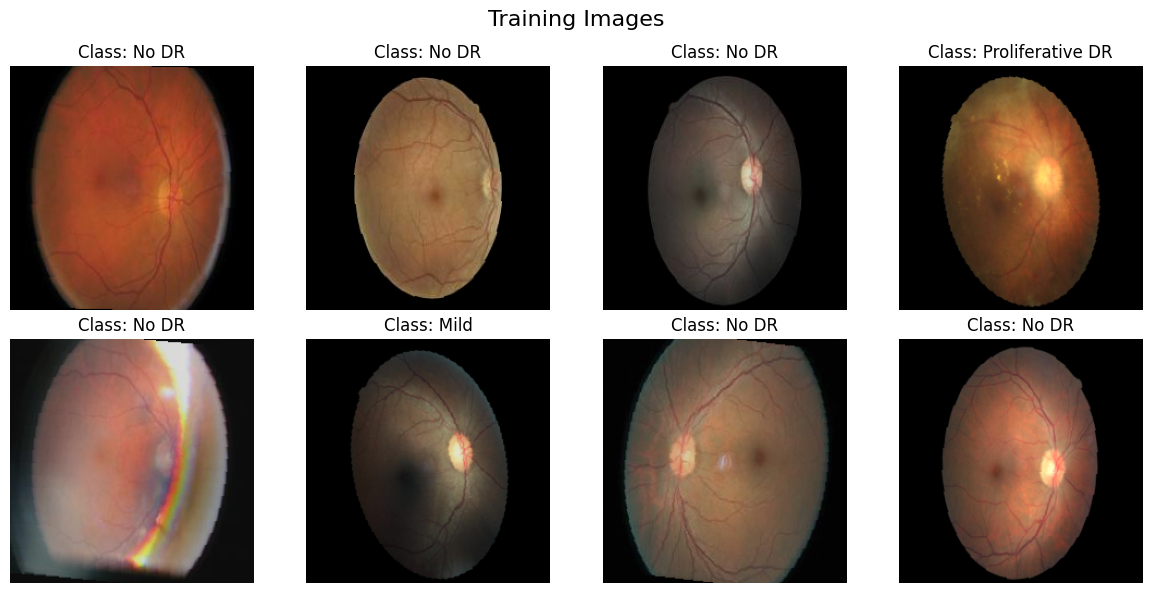

In [82]:
# Visualize Images
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

# Get a batch of images
images, labels = next(iter(train_loader))

# Denormalize images for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)# Visualize Images
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

# Get a batch of images
images, labels = next(iter(train_loader))

# Denormalize images for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
images_display = images[:8] * std + mean  # Undo normalization

# Plot
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('Training Images', fontsize=16)

class_names = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]

for idx, ax in enumerate(axes.flat):
    img = images_display[idx].permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)  # Clip to [0, 1]
    
    ax.imshow(img)
    ax.set_title(f"Class: {class_names[labels[idx].item()]}")
    ax.axis('off')

plt.tight_layout()
plt.savefig('SplitDATA\\logs\\sample_images.png', dpi=150)
plt.show()

#print(" Images displayed!")

images_display = images[:8] * std + mean  # Undo normalization

# Plot
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('Training Images', fontsize=16)

class_names = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]

for idx, ax in enumerate(axes.flat):
    img = images_display[idx].permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(f"Class: {class_names[labels[idx].item()]}")
    ax.axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/SplitDATA/logs/sample_images.png', dpi=150)  # ← fixed
plt.show()

In [83]:
# Creating MobileNetV2 Model
import torch
import torch.nn as nn
import torchvision.models as models

# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Load MobileNetV2 model
print("\nLoading MobileNetV2 model...")
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

# Replace the classifier head for 5 DR severity levels
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(model.last_channel, 5)
)

# Move to device
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n✓ MobileNetV2 loaded!")
print(f"  Total parameters:     {total_params/1e6:.2f}M")
print(f"  Trainable parameters: {trainable_params/1e6:.2f}M")
print(f"  Model: MobileNetV2 (pretrained on ImageNet)")
print(f"  Output classes: 5 (DR severity levels)")


Using device: cuda
GPU: Tesla T4
Memory: 15.64 GB

Loading MobileNetV2 model...
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 133MB/s]



✓ MobileNetV2 loaded!
  Total parameters:     2.23M
  Trainable parameters: 2.23M
  Model: MobileNetV2 (pretrained on ImageNet)
  Output classes: 5 (DR severity levels)


In [84]:
# Setup Training Components
import torch.optim as optim

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer - slightly higher LR suits MobileNetV2
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,          # Learning rate
    weight_decay=1e-4  # Regularization
)

# Learning rate scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=12,
    eta_min=1e-6
)

print("✓ Training components ready!")
print(f"  Loss function: CrossEntropyLoss")
print(f"  Optimizer:     AdamW")
print(f"  Learning rate: 1e-4")
print(f"  Scheduler:     CosineAnnealing")


✓ Training components ready!
  Loss function: CrossEntropyLoss
  Optimizer:     AdamW
  Learning rate: 1e-4
  Scheduler:     CosineAnnealing


In [85]:
# to Train Model 
import numpy as np
from tqdm import tqdm
from sklearn.metrics import accuracy_score

# Training parameters
num_epochs = 12
best_val_acc = 0
patience = 10
patience_counter = 0

# History
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

print("Training process: ")

for epoch in range(1, num_epochs + 1):
    model.train()  # Training model
    train_loss = 0
    train_preds = []
    train_labels = []
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch} Train", leave=False):

        images = images.to(device)
        labels = labels.to(device)
        #£Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        #£Backward pass
        optimizer.zero_grad()  # Clear previous gradients
        loss.backward()         # Compute gradients
        optimizer.step()        # Update weights
        #£Track metrics
        train_loss += loss.item()
        _, preds = outputs.max(1)
        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())
    
    train_loss = train_loss / len(train_loader)
    train_acc = accuracy_score(train_labels, train_preds)
    
    #VALIDATION 
    model.eval()  # Evaluation
    val_loss = 0
    val_preds = []
    val_labels = []
    
    with torch.no_grad():  # Don't compute gradients
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch} Val", leave=False):
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, preds = outputs.max(1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())
    
    val_loss = val_loss / len(val_loader)
    val_acc = accuracy_score(val_labels, val_preds)
    
    # Updating lR
    scheduler.step()
    
    # Record history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Print progress
    print(f"Epoch {epoch:3d}/{num_epochs} | "
          f"TrLoss: {train_loss:.4f} | TrAcc: {train_acc*100:.2f}% | "
          f"VlLoss: {val_loss:.4f} | VlAcc: {val_acc*100:.2f}%", end="")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'SplitDATA/checkpoints/best_model.pth')
        print(" ✓ (New best!)")
    else:
        patience_counter += 1
        print()
        
        # Early stopping
        if patience_counter >= patience:
            print(f"\nEarly stopping! No improvement for {patience} epochs.")
            break

print(f"Training complete! Best validation accuracy: {best_val_acc*100:.2f}%")

Training process: 


Epoch   1/12 | TrLoss: 0.7369 | TrAcc: 75.36% | VlLoss: 3.0028 | VlAcc: 78.11% ✓ (New best!)


Epoch   2/12 | TrLoss: 0.6609 | TrAcc: 77.72% | VlLoss: 2.8362 | VlAcc: 79.17% ✓ (New best!)


Epoch   3/12 | TrLoss: 0.6265 | TrAcc: 78.78% | VlLoss: 2.7182 | VlAcc: 80.03% ✓ (New best!)


Epoch   4/12 | TrLoss: 0.5989 | TrAcc: 79.65% | VlLoss: 2.6083 | VlAcc: 80.58% ✓ (New best!)


...

Epoch   8/12 | TrLoss: 0.4609 | TrAcc: 83.69% | VlLoss: 1.9246 | VlAcc: 85.43% ✓ (New best!)


Epoch   9/12 | TrLoss: 0.4265 | TrAcc: 84.73% | VlLoss: 1.7513 | VlAcc: 86.55% ✓ (New best!)


Epoch  10/12 | TrLoss: 0.3907 | TrAcc: 85.86% | VlLoss: 1.6076 | VlAcc: 87.48% ✓ (New best!)


Epoch  11/12 | TrLoss: 0.3673 | TrAcc: 86.77% | VlLoss: 1.5336 | VlAcc: 88.21% ✓ (New best!)


Epoch  12/12 | TrLoss: 0.3547 | TrAcc: 87.20% | VlLoss: 1.4939 | VlAcc: 88.54% ✓ (New best!)
Training complete! Best validation accuracy: 88.54%


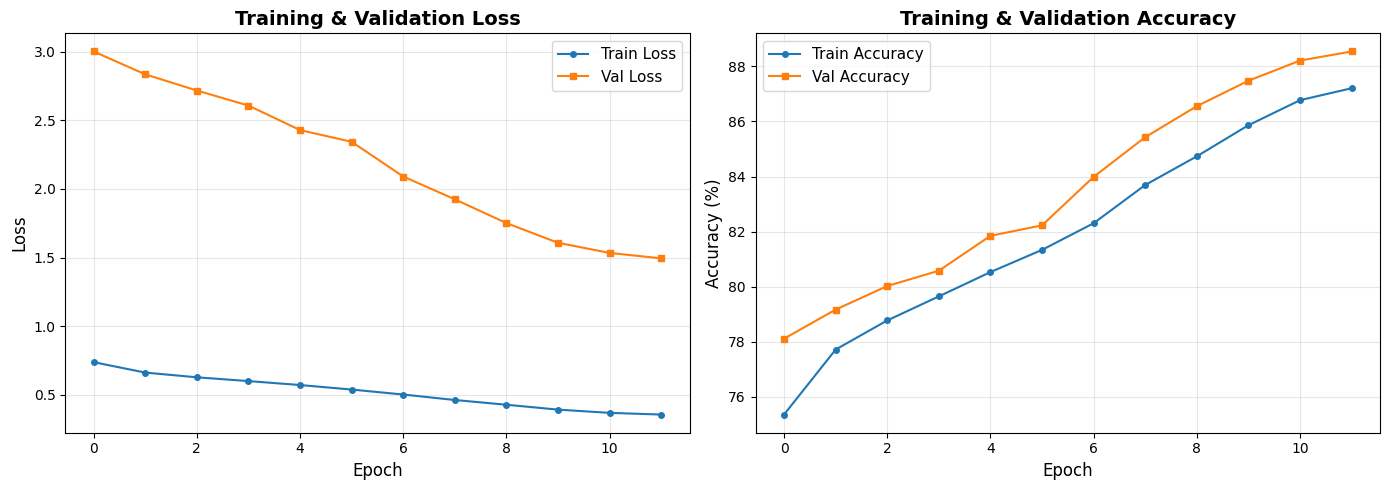

In [86]:
# Plot Training Results
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', markersize=4)
axes[0].plot(history['val_loss'], label='Val Loss', marker='s', markersize=4)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot Accuracy
train_acc_pct = [acc * 100 for acc in history['train_acc']]
val_acc_pct = [acc * 100 for acc in history['val_acc']]

axes[1].plot(train_acc_pct, label='Train Accuracy', marker='o', markersize=4)
axes[1].plot(val_acc_pct, label='Val Accuracy', marker='s', markersize=4)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('SplitDATA/logs', dpi=300, bbox_inches='tight')
plt.show()



In [87]:
# Testing on Test Set
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np

# Load best MobileNetV2 model
model = models.mobilenet_v2(weights=None)
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(model.last_channel, 5)
)
model.load_state_dict(torch.load('SplitDATA/checkpoints/best_model.pth', map_location=device))
model = model.to(device)
model.eval()

# Test
test_preds = []
test_labels = []

print("Testing on test set...")
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(device)

        outputs = model(images)
        _, preds = outputs.max(1)

        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

# Calculate metrics
test_acc = accuracy_score(test_labels, test_preds)
cm = confusion_matrix(test_labels, test_preds)

print("Test RESULTS:")
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

# Class-wise accuracy
class_names = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]
print("\nClass-wise Accuracy:")
for i in range(5):
    class_acc = cm[i, i] / cm[i].sum() * 100
    print(f"  {class_names[i]:20s}: {class_acc:.2f}%")

print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=class_names))


Testing on test set...


Testing: 100%|██████████| 330/330 [00:46<00:00,  7.11it/s]

Test RESULTS:

Test Accuracy: 81.64%

Class-wise Accuracy:
  No DR               : 94.72%
  Mild                : 9.25%
  Moderate            : 57.05%
  Severe              : 55.51%
  Proliferative DR    : 71.50%

Classification Report:
                  precision    recall  f1-score   support

           No DR       0.86      0.95      0.90      7743
            Mild       0.35      0.09      0.15       735
        Moderate       0.65      0.57      0.61      1588
          Severe       0.66      0.56      0.60       263
Proliferative DR       0.75      0.71      0.73       214

        accuracy                           0.82     10543
       macro avg       0.65      0.58      0.60     10543
    weighted avg       0.79      0.82      0.79     10543



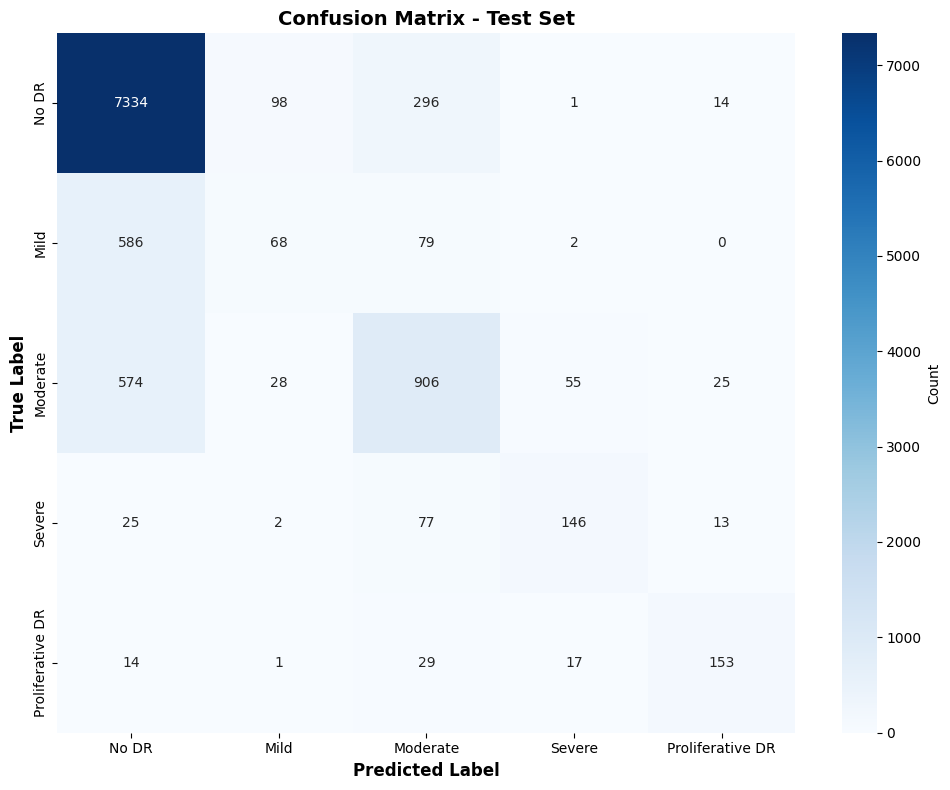

Confusion matrix done!


In [89]:
# Confusion Matrix
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'}, ax=ax)

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('SplitDATA/logs/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrix done!")